In [131]:
import pandas as pd
import numpy as np
from src import run_experiment, Config
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer, KNNImputer
from matplotlib import pyplot as plt
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score


In [132]:
df = pd.read_csv('../data/app_train_new.csv')

/var/folders/8r/46ncjmbn5rq0s4d0hqmk4f440000gn/T/ipykernel_25983/4227906376.py:1: DtypeWarning: Columns (123) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/app_train_new.csv')


In [138]:
df = df[features_most]

In [140]:
from catboost import CatBoostClassifier, cv, Pool

num_cols = df.select_dtypes(include='number').columns
cat_cols = df.select_dtypes(exclude='number').columns

if 'TARGET' in df.columns:
    target = df['TARGET']
    df.drop(columns=['TARGET'], inplace=True)

In [141]:
df[cat_cols] = df[cat_cols].fillna('none').astype(str)

In [142]:
X_train, X_test, y_train, y_test = train_test_split(df, target, test_size=0.2, shuffle=True, stratify=target)


In [143]:
df.shape

(307510, 221)

In [ ]:
model_cat = CatBoostClassifier(
    iterations=600
)

model_cat.fit(X_train, y_train, cat_features=list(cat_cols))

Learning rate set to 0.172705
0:	learn: 0.5371281	total: 88.7ms	remaining: 53.1s
1:	learn: 0.4404501	total: 183ms	remaining: 54.8s
2:	learn: 0.3811840	total: 300ms	remaining: 59.8s
3:	learn: 0.3437207	total: 420ms	remaining: 1m 2s
4:	learn: 0.3202088	total: 527ms	remaining: 1m 2s
5:	learn: 0.3050607	total: 628ms	remaining: 1m 2s
6:	learn: 0.2945858	total: 714ms	remaining: 1m
7:	learn: 0.2883168	total: 821ms	remaining: 1m
8:	learn: 0.2833543	total: 929ms	remaining: 1m
9:	learn: 0.2799424	total: 1.03s	remaining: 1m
10:	learn: 0.2772255	total: 1.13s	remaining: 1m
11:	learn: 0.2756318	total: 1.22s	remaining: 59.8s
12:	learn: 0.2743761	total: 1.36s	remaining: 1m 1s
13:	learn: 0.2733821	total: 1.49s	remaining: 1m 2s
14:	learn: 0.2724808	total: 1.59s	remaining: 1m 2s
15:	learn: 0.2717563	total: 1.73s	remaining: 1m 2s
16:	learn: 0.2712779	total: 1.84s	remaining: 1m 3s
17:	learn: 0.2708062	total: 1.97s	remaining: 1m 3s
18:	learn: 0.2704249	total: 2.1s	remaining: 1m 4s
19:	learn: 0.2700849	total

In [146]:
y_pred = model_cat.predict_proba(X_test)[:,1]

print(roc_auc_score(y_test, y_pred))

# 0.770395

0.6711664407275928


In [127]:
importances = np.array(model_cat.get_feature_importance())
idx_sorted = np.argsort(importances)
importances = importances[idx_sorted]
features = list(df.columns[idx_sorted])

In [128]:
mask = importances > 0.1
imp_most = importances[mask]

features_most = features[:imp_most.shape[0]]

<BarContainer object of 221 artists>

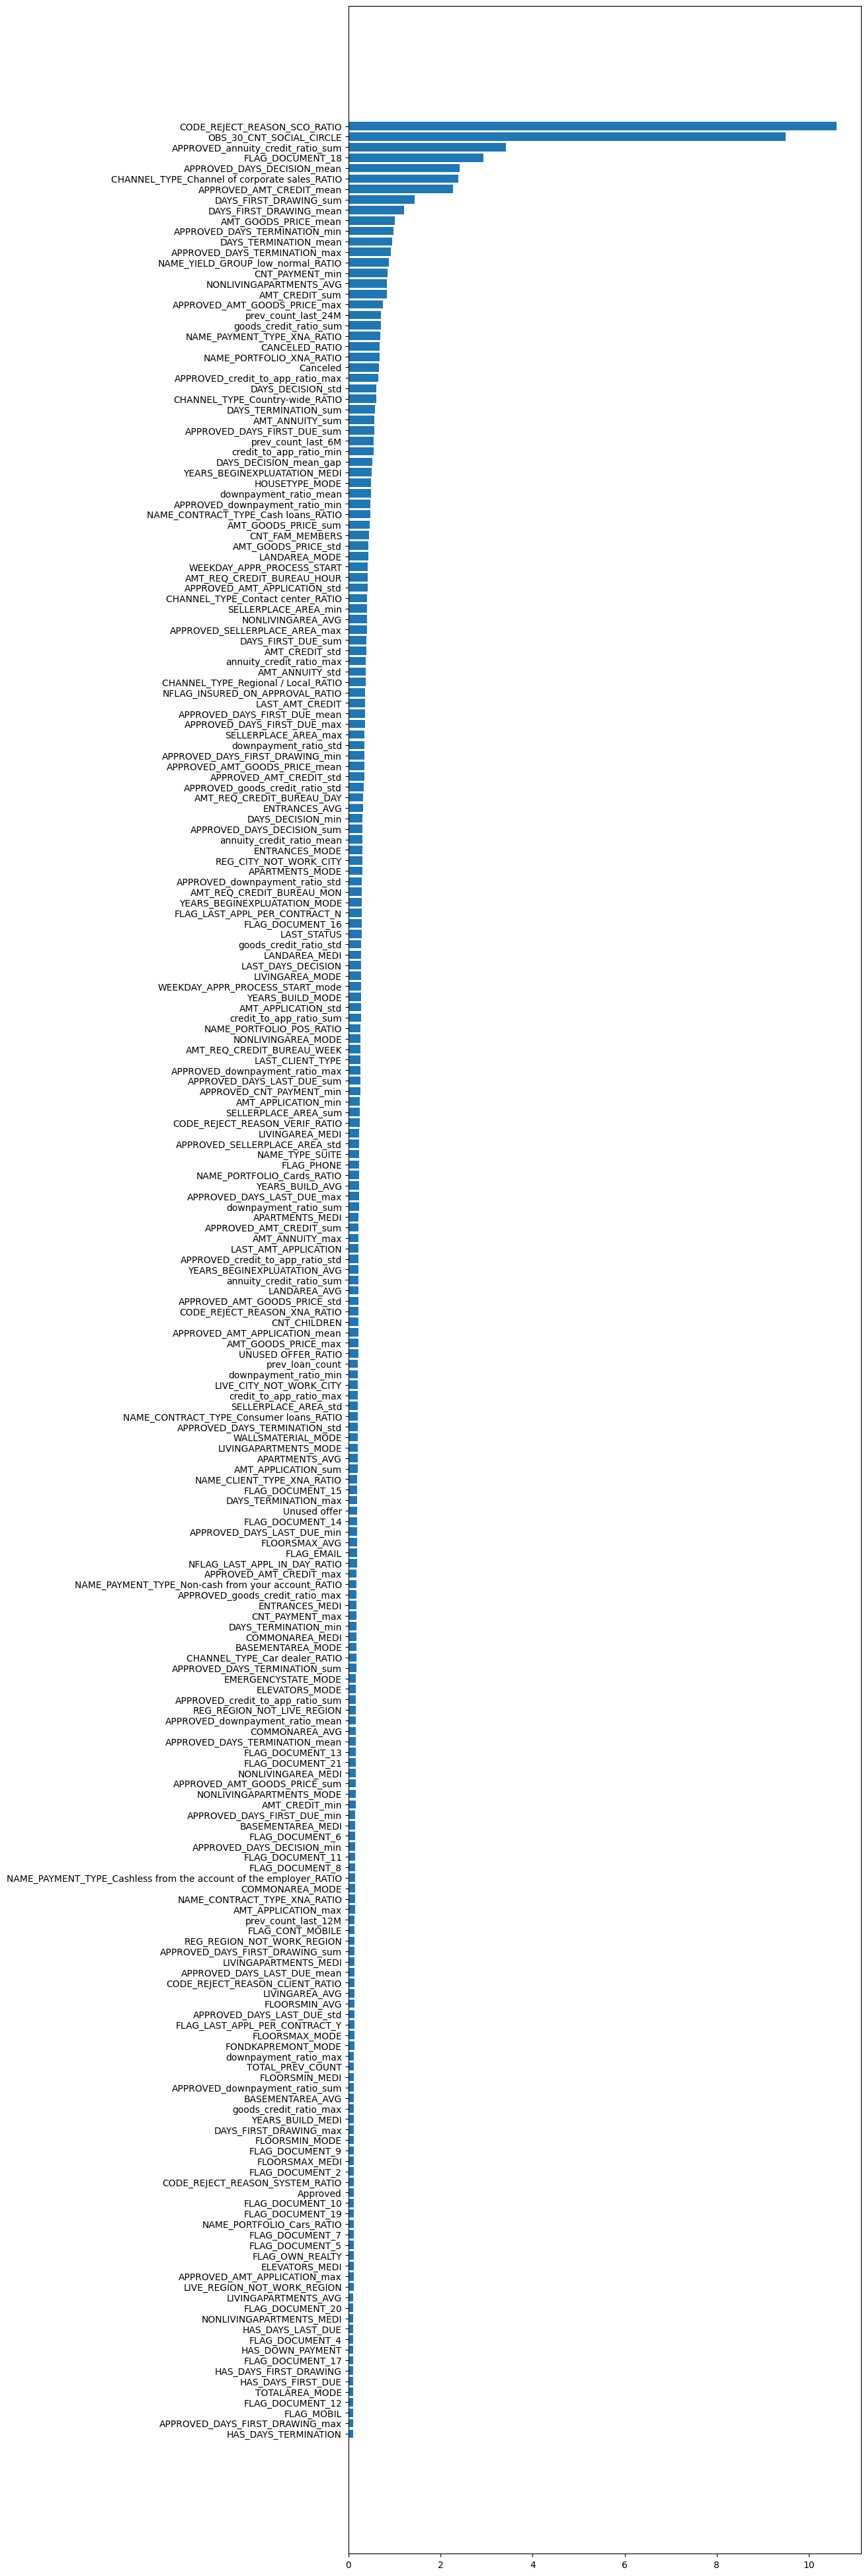

In [130]:
plt.figure(figsize=(10, 50))
plt.barh(features_most, imp_most)

In [4]:
# Солвер 'saga' с penalty='elasticnet' очень долго сходится, поэтому сделаем пока чистую L2-регуляризацию
def log_reg_param_space(trial):
    return {
        "C": trial.suggest_float('C', 1e-3, 1e2, log=True),
        # "l1_ratio": trial.suggest_float('l1_ratio', 0, 1, step=0.1),
        # "penalty": trial.suggest_categorical('penalty', ['elasticnet']),
        # "solver": trial.suggest_categorical('solver', ['saga']),
        "max_iter": trial.suggest_int('max_iter', 100, 1000, step=100)
    }

# exp_name_lr = f'90_nan'

# pipeline_lr, results = run_experiment(
#     exp_name_lr,
#     LogisticRegression,
#     log_reg_param_space,
#     df,
#     n_trials=1,
#     cv_num=5,
#     save_model=True
# )

In [5]:
from sklearn.tree import DecisionTreeClassifier

def decision_tree_param_space(trial):
    return {
        "criterion": trial.suggest_categorical("criterion", ["gini", "entropy", "log_loss"]),
        "max_depth": trial.suggest_int("max_depth", 1, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None])
    }

exp_name_dt = f'90_nan'

# run_experiment(
#     exp_name_dt,
#     DecisionTreeClassifier,
#     decision_tree_param_space,
#     df,
#     n_trials=1,
#     cv_num=2,
#     save_model=True
# )

In [6]:
from sklearn.ensemble import RandomForestClassifier

def random_forest_param_space(trial):
    return {
        "n_estimators": trial.suggest_int("n_estimators", 100, 300),
        "max_depth": trial.suggest_int("max_depth", 1, 13),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False])
    }

exp_name_rf = f'90_nan'

# run_experiment(
#     exp_name_rf,
#     RandomForestClassifier,
#     random_forest_param_space,
#     df,
#     n_trials=1,
#     cv_num=2,
#     save_model=True
# )

In [7]:
from catboost import CatBoostClassifier, cv, Pool

def catboost_param_space(trial):
    return {
        "iterations": trial.suggest_int("iterations", 100, 600),
        "depth": trial.suggest_int("depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "border_count": trial.suggest_int("border_count", 32, 255),
        "random_strength": trial.suggest_float("random_strength", 0, 1),
        
        'loss_function': 'Logloss',
        'eval_metric': 'AUC',
        
        "bootstrap_type": "Bernoulli",
        "subsample": trial.suggest_float("subsample", 0.5, 1),
        
        "verbose": False,
        "random_state": Config.SEED,

        "od_type": 'Iter',
        "od_wait": 30
        # Golden features
        # --per-float-feature-quantization 0:border_count=1024;1:border_count=1024
    }

# feature_importances_ shap

exp_name_cb = f'90_nan'

catboost_pipeline, results = run_experiment(
    exp_name_cb,
    CatBoostClassifier,
    catboost_param_space,
    df,
    n_trials=1,
    cv_num=2,
    save_model=False
)

# num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
# cat_cols = df.select_dtypes(include=['object']).columns.tolist()

# df_imputed = pd.concat([df[num_cols], df[cat_cols].fillna('NA')], axis=1)
# target = df_imputed['TARGET']

# if 'TARGET' in df_imputed.columns:
#     df_imputed.drop(columns=['TARGET'], inplace=True)

# pool = Pool(df_imputed, label=target, cat_features=cat_cols)

[I 2026-05-09 16:55:40,641] Using an existing study with name 'CatBoostClassifier' instead of creating a new one.
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   2 | elapsed:  1.5min finished
[I 2026-05-09 16:57:11,475] Trial 16 finished with value: 0.7390783657596738 and parameters: {'iterations': 287, 'depth': 10, 'learning_rate': 0.1205712628744377, 'l2_leaf_reg': 6.387926357773329, 'border_count': 66, 'random_strength': 0.15599452033620265, 'subsample': 0.5290418060840998}. Best is trial 13 with value: 0.7390783657596738.


0:	learn: 0.5653577	total: 239ms	remaining: 1m 8s
1:	learn: 0.4773126	total: 545ms	remaining: 1m 17s
2:	learn: 0.4147653	total: 886ms	remaining: 1m 23s
3:	learn: 0.3706082	total: 1.18s	remaining: 1m 23s
4:	learn: 0.3386891	total: 1.52s	remaining: 1m 25s
5:	learn: 0.3161295	total: 1.9s	remaining: 1m 28s
6:	learn: 0.2995963	total: 2.19s	remaining: 1m 27s
7:	learn: 0.2865405	total: 2.58s	remaining: 1m 30s
8:	learn: 0.2774862	total: 2.95s	remaining: 1m 31s
9:	learn: 0.2704703	total: 3.31s	remaining: 1m 31s
10:	learn: 0.2649525	total: 3.62s	remaining: 1m 30s
11:	learn: 0.2607636	total: 4s	remaining: 1m 31s
12:	learn: 0.2574953	total: 4.29s	remaining: 1m 30s
13:	learn: 0.2547038	total: 4.64s	remaining: 1m 30s
14:	learn: 0.2528594	total: 4.96s	remaining: 1m 29s
15:	learn: 0.2511696	total: 5.3s	remaining: 1m 29s
16:	learn: 0.2498122	total: 5.66s	remaining: 1m 29s
17:	learn: 0.2485221	total: 5.99s	remaining: 1m 29s
18:	learn: 0.2474457	total: 6.34s	remaining: 1m 29s
19:	learn: 0.2465068	total: 

KeyboardInterrupt: 

In [ ]:
# Сразу же удалим столбцы, в которых слишком большой процент пропусков
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 1]

In [ ]:
cols_to_drop = missing_pct.index[missing_pct > 10].tolist()
df = df.drop(columns=cols_to_drop)

In [ ]:
cv_results = cv(
    pool=pool,
    params={
        "iterations": 800,
        "depth": 6,
        "learning_rate": 0.1,
        "l2_leaf_reg": 3,
        "border_count": 32,
        "random_strength": 0.1,
        'loss_function': 'Logloss',
        'eval_metric': 'AUC',
        "bootstrap_type": "Bernoulli",
        "subsample": 0.8,
        "verbose": True,
        "random_state": Config.SEED,
        "od_type": 'Iter',
        "od_wait": 30
    },
    nfold=5,
    stratified=True,
    shuffle=True,
    plot=True
    
)

In [ ]:
cv_results['test-AUC-mean'].max()

In [ ]:
from lightgbm import LGBMClassifier

def lightgbm_param_space(trial):
    return {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 2, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 20, 150),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        # "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "objective": "binary",
        "data_sample_strategy": "goss",
        # "early_stopping_round": 50, необходимо передать в fit, а не в конструктор модели
        "metric": "auc",
        "verbose": -1,
        "random_state": Config.SEED
        # можно добавить использование cat_features
    }

# exp_name_lgbm = f'90_nan'

# run_experiment(
#     exp_name_lgbm,
#     LGBMClassifier,
#     lightgbm_param_space,
#     df,
#     n_trials=1,
#     cv_num=5,
#     save_model=False
# )

In [ ]:
from xgboost import XGBClassifier

def xgboost_param_space(trial):
    return {
        "verbosity": 0,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 10),
        "n_estimators": trial.suggest_int("n_estimators", 100, 600),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "scale_pos_weight": trial.suggest_categorical("scale_pos_weight", [1, 11]),
        "objective": "binary:logistic",
        "eval_metric": 'auc',
        "seed": Config.SEED,

        # "gamma"
        # "max_cat_to_onehot"
        # "max_cat_threshold"
        # можно добавить использование cat_features
    }

# mask = target == 0
# sum_pos = np.sum(target, axis=0)
# sum_neg = np.sum(mask)
# print(sum_pos)
# print(sum_neg)
# scale_pos_weight = sum_neg / sum_pos
# print(scale_pos_weight) = 11

exp_name_xgb = f'90_nan'

# CMA-ES с Warm-Starting 
# Meta-Learn TPE — Лучший выбор для TPE

run_experiment(
    exp_name_xgb,
    XGBClassifier,
    xgboost_param_space,
    df,
    n_trials=10,
    cv_num=5,
    save_model=False
)

# Export to the PROD

Из всех моделей осталось выбрать наилучшую по Kaggle-score и дальше через FastAPI & Streamlit UI сделать полноценное приложение.